## Repeated K-Fold cross-validation

Performs repeated stratified K-fold cross-validation in which feature extraction (DiscriminantPursuit) and classification (RandomForestClassifier) are both fitted within each fold, preventing data leakage. After CV, feature importance is estimated two ways:

  1. Gini (MDI) importance — the default sklearn measure. Known to be biased toward features with high cardinality or correlated predictors (Strobl et al., 2007; doi:10.1186/1471-2105-8-25). Reported here for reference.

  2. Permutation importance — shuffles each feature and measures the drop in out-of-bag accuracy. Unbiased and recommended for interpretation (Strobl et al., 2007). Computed on a held-out test split so that importance reflects generalization, not in-sample fit.  

### References
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures: Illustrations, sources and a solution. BMC Bioinformatics, 8, 25. https://doi.org/10.1186/1471-2105-8-25
- Buckheit, J. & Donoho, D. L. (1995). Improved linear discrimination using time-frequency dictionaries. Proc. SPIE, 2569, 540–551.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder

from scipy.ndimage import uniform_filter1d  # for generating test data

from discr_pursuit import DiscriminantPursuit

### Data

In [2]:
def load_data(seed=0, noise_scale=1.0):
    """
    Synthetic dataset with additive Gaussian noise.

    Each class is a sinusoid at a distinct frequency (6, 8, 10 Hz) with
    independent Gaussian noise added. The noise_scale parameter controls
    the standard deviation of the noise relative to the signal amplitude
    (0.8), so noise_scale=1.0 gives an SNR of roughly 0.8.

    Replace with your own time-series data:
        X : ndarray, shape (n_samples, n_timepoints)
            n_timepoints must be a power of 2 (e.g., 128, 256, 512).
        y : array-like, shape (n_samples,)
            Class labels (integer or string).
    Example with real data:
        import numpy as np
        data = np.load("my_timeseries.npz")
        X, y = data["X"], data["y"]
    """
    rng = np.random.default_rng(seed)
    n_samples   = 300
    n_timepoints = 128          # must be 2**J
    n_classes   = 3
    t           = np.linspace(0, 1, n_timepoints)

    # Pure noise baseline
    X = rng.standard_normal((n_samples, n_timepoints)) * noise_scale

    y = rng.integers(0, n_classes, size=n_samples)

    # Inject a class-discriminant sinusoid
    signal_amp = 0.8
    freqs = [6, 8, 10]
    for cls in range(n_classes):
        idx = y == cls
        X[idx] += signal_amp * np.sin(2 * np.pi * freqs[cls] * t)

    le = LabelEncoder()
    y = le.fit_transform(y)
    return X, y, le.classes_

### Cross-validation

In [3]:
def run_cv(X, y, args):
    """
    Repeated stratified K-fold CV with DiscriminantPursuit + RandomForest.

    Both DiscriminantPursuit and RandomForestClassifier are fitted inside
    each fold via a Pipeline, so no feature information from the test fold
    leaks into the extractor.
    """
    cv = RepeatedStratifiedKFold(
        n_splits=args['folds'],
        n_repeats=args['rounds'],
        random_state=args['seed'],
    )

    pipe = make_pipeline(
        DiscriminantPursuit(
            n_coef=args['n_coef'],
            filter_family=args['filter_family'],
            filter_par=args['filter_par'],
        ),
        RandomForestClassifier(
            n_estimators=args['n_trees'],
            random_state=args['seed'],
            n_jobs=-1,
        ),
    )

    fold_scores = []
    n_total = args['rounds'] * args['folds']
    print(
        f"\nRunning {args['rounds']} x {args['folds']}-fold CV "
        f"({n_total} total fits)...\n"
    )

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe.fit(X_train, y_train)
        acc = pipe.score(X_test, y_test)
        fold_scores.append(acc)

        if fold_idx % args['folds'] == 0:
            round_num = fold_idx // args['folds']
            round_scores = fold_scores[-args['folds']:]
            print(
                f"  Round {round_num:>{len(str(args['rounds']))}}/{args['rounds']} — "
                f"mean acc: {np.mean(round_scores):.3f}  "
                f"std: {np.std(round_scores):.3f}"
            )

    fold_scores = np.array(fold_scores)
    print(
        f"\nOverall ({n_total} folds): "
        f"mean = {fold_scores.mean():.3f}, "
        f"std  = {fold_scores.std():.3f}, "
        f"min  = {fold_scores.min():.3f}, "
        f"max  = {fold_scores.max():.3f}\n"
    )
    return fold_scores

### Feature importance

In [4]:
def compute_importance(X, y, args):
    """
    Fit a final model on a train split and compute feature importance on
    a held-out test split.

    Gini (MDI) importance is reported with a warning following
    Strobl et al. (2007): it is biased when features differ in scale or
    when predictors are correlated.

    Permutation importance is computed on the held-out test set, which
    makes it a measure of generalization contribution rather than in-sample
    fit. This is the recommended approach (Strobl et al., 2007).
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=args['seed']
    )

    dp = DiscriminantPursuit(
        n_coef=args['n_coef'],
        filter_family=args['filter_family'],
        filter_par=args['filter_par'],
    )
    rf = RandomForestClassifier(
        n_estimators=args['n_trees'],
        random_state=args['seed'],
        n_jobs=-1,
    )

    X_train_feat = dp.fit_transform(X_train, y_train)
    X_test_feat  = dp.transform(X_test)
    rf.fit(X_train_feat, y_train)

    # Feature labels: (depth, block, translation) from packet tree
    feat_labels = [
        f"d{d}b{b}k{k}"
        for d, b, k in dp.packet_indices_
    ]

    results = {}

    if args['importance'] in ("gini", "both"):
        gini_imp = rf.feature_importances_
        results["gini"] = (feat_labels, gini_imp)
        print(
            "Gini (MDI) importance — NOTE: biased toward correlated or\n"
            "  high-variance features (Strobl et al., 2007). Use permutation\n"
            "  importance for interpretation.\n"
        )
        _print_importance(feat_labels, gini_imp, "Gini")

    if args['importance'] in ("permutation", "both"):
        perm = permutation_importance(
            rf, X_test_feat, y_test,
            n_repeats=30,
            random_state=args['seed'],
            n_jobs=-1,
        )
        results["permutation"] = (feat_labels, perm.importances_mean,
                                  perm.importances_std)
        print(
            "Permutation importance (test set) — unbiased estimate of\n"
            "  each feature's contribution to generalization accuracy\n"
            "  (Strobl et al., 2007).\n"
        )
        _print_importance(feat_labels, perm.importances_mean,
                          "Permutation", perm.importances_std)

    return results

In [5]:
def _print_importance(labels, means, method, stds=None):
    order = np.argsort(means)[::-1]
    header = f"{'Feature':<12}  {'Importance':>10}"
    if stds is not None:
        header += f"  {'± Std':>8}"
    print(f"  {method} importance (ranked):")
    print(f"  {header}")
    print(f"  {'-' * len(header)}")
    for i in order:
        row = f"  {labels[i]:<12}  {means[i]:>10.4f}"
        if stds is not None:
            row += f"  {stds[i]:>8.4f}"
        print(row)
    print()

### Plotting

In [6]:
def plot_cv_scores(fold_scores, args):
    rounds = args['rounds']
    folds  = args['folds']
    round_means = [
        fold_scores[r * folds:(r + 1) * folds].mean()
        for r in range(rounds)
    ]
    round_stds = [
        fold_scores[r * folds:(r + 1) * folds].std()
        for r in range(rounds)
    ]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Per-round summary
    ax = axes[0]
    ax.errorbar(
        range(1, rounds + 1), round_means, yerr=round_stds,
        fmt="o-", capsize=4, color="steelblue", linewidth=1.5
    )
    ax.axhline(fold_scores.mean(), color="tomato", linestyle="--",
               linewidth=1.2, label=f"Overall mean = {fold_scores.mean():.3f}")
    ax.set_xlabel("Round")
    ax.set_ylabel("Mean accuracy")
    ax.set_title(f"{rounds} × {folds}-fold CV — per-round accuracy")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

    # Distribution of all fold scores
    ax = axes[1]
    ax.hist(fold_scores, bins=15, color="steelblue", edgecolor="white",
            alpha=0.85)
    ax.axvline(fold_scores.mean(), color="tomato", linestyle="--",
               linewidth=1.5, label=f"Mean = {fold_scores.mean():.3f}")
    ax.set_xlabel("Fold accuracy")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of fold accuracies")
    ax.legend(fontsize=9)

    fig.suptitle(
        f"DiscriminantPursuit ({args['filter_family']}-{args['filter_par']}, "
        f"n_coef={args['n_coef']}) + RandomForest (n_trees={args['n_trees']})",
        fontsize=11
    )
    plt.tight_layout()

In [7]:
def plot_importance(importance_results, args):
    if not importance_results:
        return

    n_panels = len(importance_results)
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))
    if n_panels == 1:
        axes = [axes]

    colors = {"gini": "steelblue", "permutation": "seagreen"}
    titles = {
        "gini": "Gini (MDI) importance\n(biased — Strobl et al., 2007)",
        "permutation": "Permutation importance\n(unbiased — Strobl et al., 2007)",
    }

    for ax, (method, vals) in zip(axes, importance_results.items()):
        labels = vals[0]
        means  = vals[1]
        stds   = vals[2] if len(vals) > 2 else None

        order = np.argsort(means)
        y_pos = np.arange(len(labels))

        ax.barh(
            y_pos, means[order],
            xerr=stds[order] if stds is not None else None,
            color=colors[method], edgecolor="white", alpha=0.85,
            capsize=3
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels([labels[i] for i in order], fontsize=9)
        ax.set_xlabel("Importance")
        ax.set_title(titles[method], fontsize=10)
        ax.axvline(0, color="black", linewidth=0.8)

    fig.suptitle(
        f"Feature importance — {args['n_coef']} discriminant basis functions\n"
        f"(label format: d=depth, b=block, k=translation)",
        fontsize=10
    )
    plt.tight_layout()

In [8]:
def plot_importance_bar(importance_results, n_top=10):
    """
    Horizontal bar chart of top n_top features for each importance method
    present in importance_results.
    """
    n_panels = len(importance_results)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(6 * n_panels, 4),
                             constrained_layout=True)
    if n_panels == 1:
        axes = [axes]

    colors = {"gini": "steelblue", "permutation": "seagreen"}
    titles = {
        "gini":        "Gini (MDI) importance\n(biased — Strobl et al., 2007)",
        "permutation": "Permutation importance\n(unbiased — Strobl et al., 2007)",
    }

    for ax, (method, vals) in zip(axes, importance_results.items()):
        labels = np.array(vals[0])
        means  = np.array(vals[1])
        stds   = np.array(vals[2]) if len(vals) > 2 else None

        top_idx = np.argsort(means)[::-1][:n_top]
        top_idx = top_idx[::-1]   # reverse so highest bar is at top

        ax.barh(
            range(len(top_idx)),
            means[top_idx],
            xerr=stds[top_idx] if stds is not None else None,
            color=colors[method], edgecolor="white",
            alpha=0.85, capsize=3,
        )
        ax.set_yticks(range(len(top_idx)))
        ax.set_yticklabels(labels[top_idx], fontsize=9)
        ax.set_xlabel("Importance")
        ax.set_title(titles[method], fontsize=10)
        ax.axvline(0, color="black", linewidth=0.8)

In [9]:
def plot_top_features(importance_results, X, y, args, n_top=10):
    """
    Plot the top n_top discriminant basis functions ranked by importance.
    Refits DiscriminantPursuit on the full dataset to recover basis_functions_
    and packet_indices_ for visualization.
    """
    # Prefer permutation importance; fall back to Gini
    if "permutation" in importance_results:
        labels, means, stds = importance_results["permutation"]
        method_label = "Permutation importance (unbiased)"
    else:
        labels, means = importance_results["gini"]
        stds = None
        method_label = "Gini (MDI) importance — interpret with caution"

    means = np.array(means)
    top_idx = np.argsort(means)[::-1][:n_top]

    # Refit dp to access basis_functions_ and packet_indices_
    dp = DiscriminantPursuit(
        n_coef=args['n_coef'],
        filter_family=args['filter_family'],
        filter_par=args['filter_par'],
    )
    dp.fit(X, y)

    n_cols = 2
    n_rows = (n_top + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(12, n_rows * 2.4),
                             constrained_layout=True)
    axes = axes.flatten()

    for rank, feat_i in enumerate(top_idx):
        ax = axes[rank]
        d, b, k  = dp.packet_indices_[feat_i]
        waveform = dp.basis_functions_[feat_i]
        t = np.arange(len(waveform))

        ax.plot(t, waveform, color="steelblue", linewidth=1.2)
        ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
        ax.set_xlim(0, len(waveform) - 1)

        imp_text = f"{means[feat_i]:.4f}"
        if stds is not None:
            imp_text += f" ± {np.array(stds)[feat_i]:.4f}"

        ax.set_title(
            f"Rank {rank + 1}  |  {labels[feat_i]}\n"
            f"depth={d}, block={b}, translation={k}\n"
            f"importance = {imp_text}",
            fontsize=8.5,
        )
        ax.set_xlabel("Timepoint", fontsize=8)
        ax.set_ylabel("Amplitude", fontsize=8)
        ax.tick_params(labelsize=7)

    for ax in axes[n_top:]:
        ax.set_visible(False)

    fig.suptitle(
        f"Top {n_top} discriminant basis functions — {method_label}\n"
        f"{args['filter_family']}-{args['filter_par']}, "
        f"n_coef={args['n_coef']}, n_trees={args['n_trees']}",
        fontsize=10, y=1.01,
    )

### Demonstration of use

#### Parameters

- Five rounds and five folds are used here for demonstration purposes

In [10]:
args = {
    "rounds": 5,
    "folds": 5,
    "n_coef": 10,
    "filter_family": "Symmlet",
    "filter_par": 8,
    "n_trees": 500,
    "importance": "both",   # "gini" | "permutation" | "both" | "none"
    "seed": 0,
}

#### Generate data

In [11]:
# noise increased to 3 to make the data a bit more challenging
X, y, class_names = load_data(seed=args['seed'], noise_scale=3) 
print(f"Data: {X.shape[0]} samples, {X.shape[1]} timepoints, "
      f"{len(class_names)} classes {list(class_names)}\n")

Data: 300 samples, 128 timepoints, 3 classes [0, 1, 2]



#### Plot means of each class

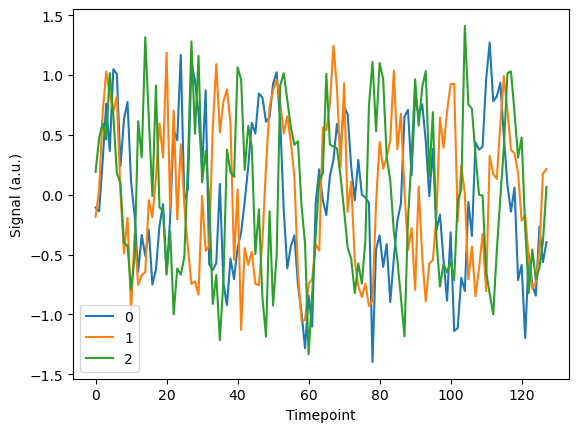

In [12]:
for i in [0,1,2]:
    plt.plot(np.mean(X[y==i,:], axis=0))
plt.xlabel('Timepoint')
plt.ylabel('Signal (a.u.)')
plt.legend(['0','1','2'])
None

#### Cross-Validation

In [13]:
cv_scores = run_cv(X, y, args)


Running 5 x 5-fold CV (25 total fits)...

  Round 1/5 — mean acc: 0.860  std: 0.048
  Round 2/5 — mean acc: 0.863  std: 0.040
  Round 3/5 — mean acc: 0.867  std: 0.053
  Round 4/5 — mean acc: 0.863  std: 0.036
  Round 5/5 — mean acc: 0.863  std: 0.046

Overall (25 folds): mean = 0.863, std  = 0.045, min  = 0.783, max  = 0.950



#### Plot results from cross-validation

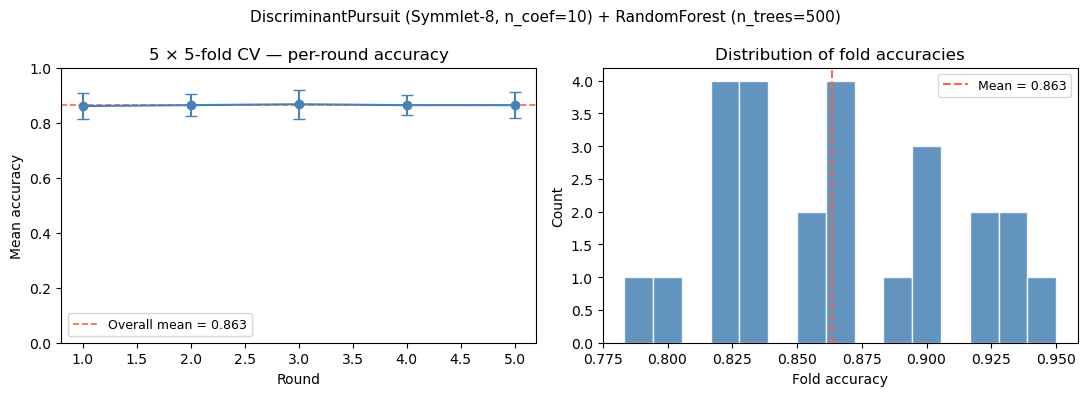

In [14]:
plot_cv_scores(cv_scores, args)

#### Plot importance scores

Gini (MDI) importance — NOTE: biased toward correlated or
  high-variance features (Strobl et al., 2007). Use permutation
  importance for interpretation.

  Gini importance (ranked):
  Feature       Importance
  ------------------------
  d7b11k0           0.2586
  d7b20k0           0.2020
  d7b16k0           0.1880
  d7b19k0           0.0895
  d0b0k78           0.0633
  d7b12k0           0.0471
  d7b15k0           0.0422
  d1b0k38           0.0411
  d0b0k126          0.0358
  d7b84k0           0.0324

Permutation importance (test set) — unbiased estimate of
  each feature's contribution to generalization accuracy
  (Strobl et al., 2007).

  Permutation importance (ranked):
  Feature       Importance     ± Std
  ----------------------------------
  d7b11k0           0.2661    0.0456
  d7b16k0           0.1611    0.0376
  d7b20k0           0.0994    0.0398
  d7b84k0           0.0217    0.0107
  d7b19k0           0.0161    0.0152
  d7b12k0           0.0111    0.0108
  d7b15k0           

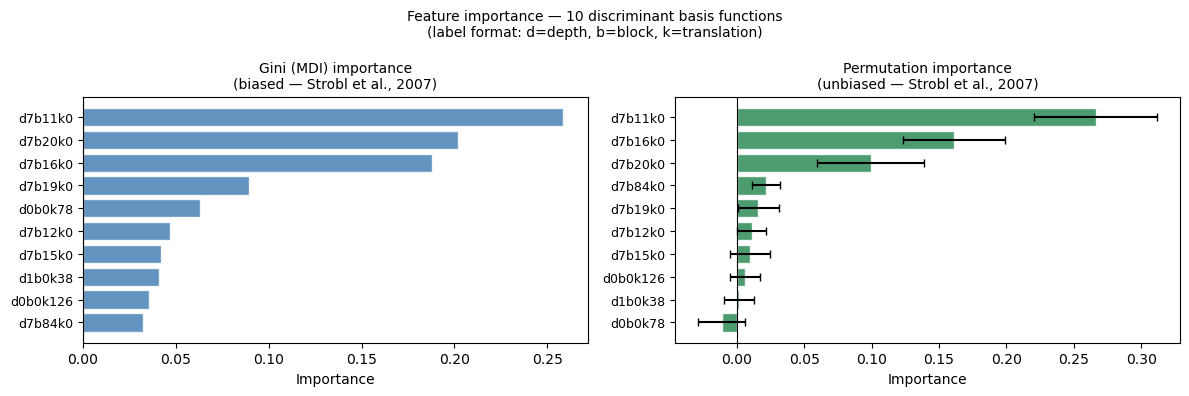

In [15]:
importance_results = compute_importance(X, y, args)
plot_importance(importance_results, args)

#### Plot of top features

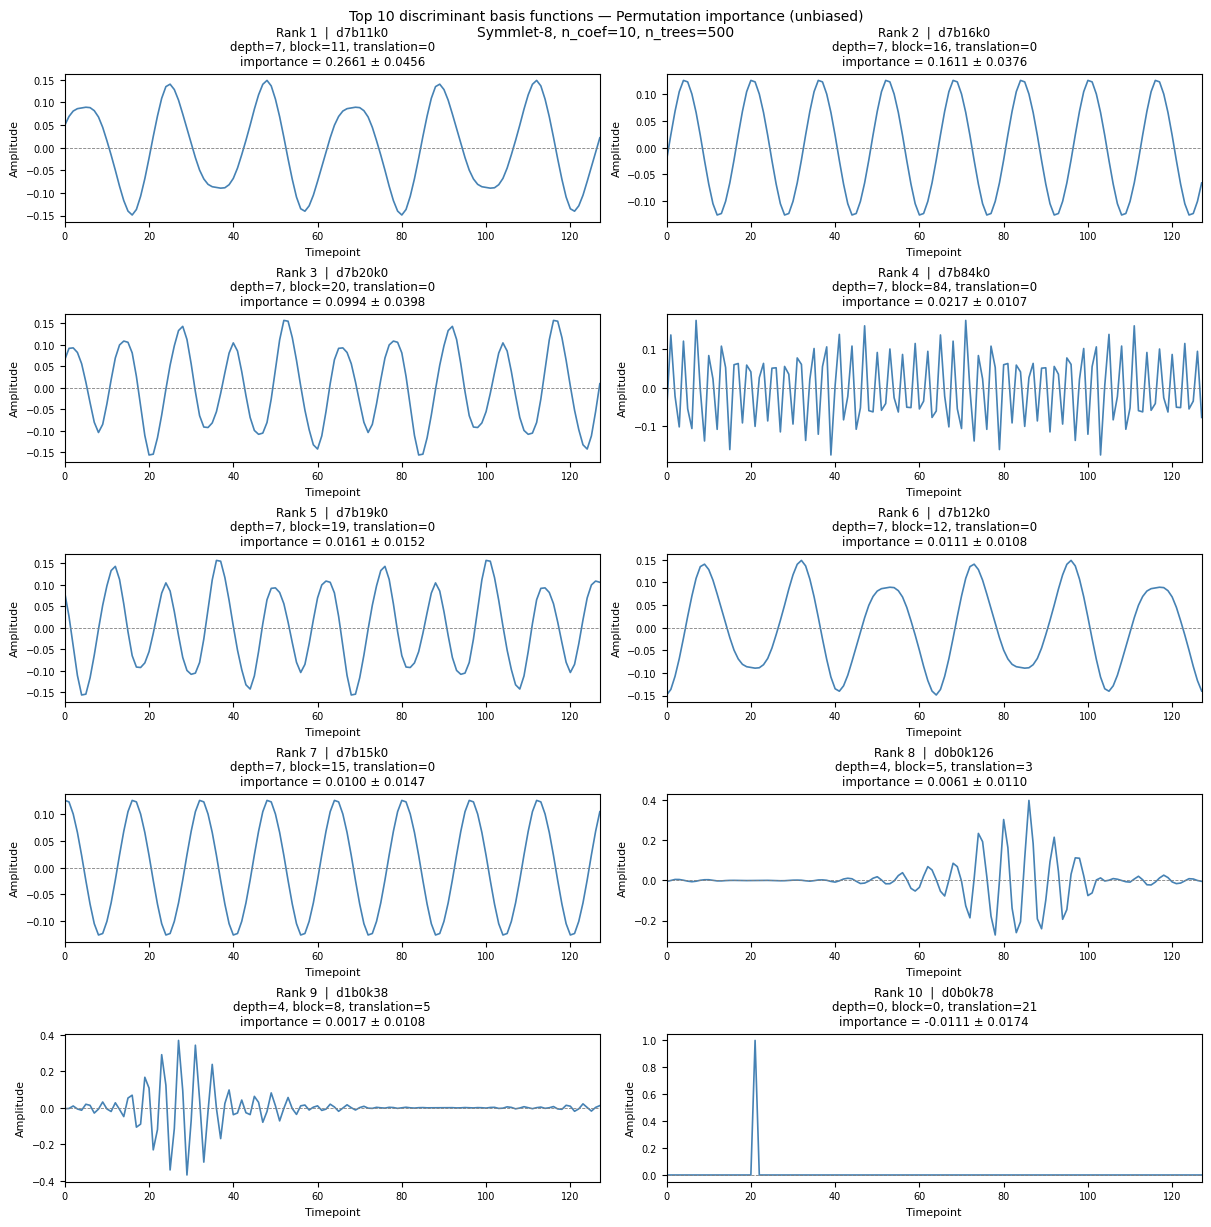

In [16]:
# Note: The function below refits on full dataset for visualization purposes. 
# Basis functions may differ slightly from those fitted within individual CV folds.
plot_top_features(importance_results, X, y, args, n_top=10)